In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path="/content/drive/MyDrive/foodexpress_orders.csv"
df=pd.read_csv(path)



In [2]:
print(df.shape)
print(df.head())
print(df.info())

(520, 22)
  order_id  order_date order_time       time_slot customer_id customer_name  \
0   FE1001  30-11-2025      10:47      Late Night     CUST035    Yash Gupta   
1   FE1002  07-01-2026      23:31          Dinner     CUST044    Sai Chopra   
2   FE1003  17-05-2026      11:40          Dinner     CUST001   Sneha Gupta   
3   FE1004  20-11-2025      11:34  Evening Snacks     CUST003   Ayaan Singh   
4   FE1005  23-05-2026      08:57       Breakfast     CUST079    Rohan Iyer   

        city restaurant_id   restaurant_name  cuisine_type  ...  discount_pct  \
0      Delhi       REST009        Noodle Bar       Chinese  ...             0   
1     Mumbai       REST021  Paradise Biryani       Biryani  ...             0   
2      Delhi       REST011        Dragon Wok       Chinese  ...            15   
3      Delhi       REST004       South Spice  South Indian  ...             0   
4  Hyderabad       REST012        Sushi Spot      Japanese  ...            25   

   discount_applied  final_a

In [3]:
print(df.isnull().sum())
print(round((df.isnull().sum() / len(df)) * 100))

order_id                 0
order_date               0
order_time               0
time_slot                0
customer_id              0
customer_name            0
city                     0
restaurant_id            0
restaurant_name          0
cuisine_type             0
items_ordered            0
order_value              0
discount_pct             0
discount_applied         0
final_amount             0
payment_method           0
distance_km              0
delivery_partner_id      0
delivery_time_mins      56
order_status             0
cancellation_reason    464
customer_rating         56
dtype: int64
order_id                0.0
order_date              0.0
order_time              0.0
time_slot               0.0
customer_id             0.0
customer_name           0.0
city                    0.0
restaurant_id           0.0
restaurant_name         0.0
cuisine_type            0.0
items_ordered           0.0
order_value             0.0
discount_pct            0.0
discount_applied        0.0
f

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['order_date'] = df['order_date'].str.strip()
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             520 non-null    object        
 1   order_date           520 non-null    datetime64[ns]
 2   order_time           520 non-null    object        
 3   time_slot            520 non-null    object        
 4   customer_id          520 non-null    object        
 5   customer_name        520 non-null    object        
 6   city                 520 non-null    object        
 7   restaurant_id        520 non-null    object        
 8   restaurant_name      520 non-null    object        
 9   cuisine_type         520 non-null    object        
 10  items_ordered        520 non-null    int64         
 11  order_value          520 non-null    float64       
 12  discount_pct         520 non-null    int64         
 13  discount_applied     520 non-null  

/tmp/ipykernel_15272/2138141800.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'])


In [6]:
df["order_month"]=df["order_date"].dt.month
df["order_day_ofweek"]=df["order_date"].dt.day_name()

In [7]:
print(df['order_day_ofweek'].value_counts())
print(df['order_month'].value_counts())

order_day_ofweek
Saturday     81
Tuesday      79
Thursday     77
Friday       76
Wednesday    73
Monday       68
Sunday       66
Name: count, dtype: int64
order_month
11    88
12    86
3     77
4     75
1     67
5     65
2     62
Name: count, dtype: int64


In [8]:
df[['order_value', 'final_amount', 'distance_km', 'delivery_time_mins', 'customer_rating']].describe()

,order_value,final_amount,distance_km,delivery_time_mins,customer_rating
count,520.000000,520.000000,520.000000,464.000000,464.000000
mean,974.680904,875.505096,6.476923,32.002155,4.035345
std,654.138055,589.674117,3.307434,13.279273,0.769028
min,77.730000,64.250000,0.800000,12.000000,1.600000
25%,437.600000,400.132500,3.575000,22.750000,3.600000
50%,820.745000,770.225000,6.400000,31.000000,4.200000
75%,1375.612500,1205.372500,9.300000,39.000000,4.600000
max,3097.640000,3097.640000,12.500000,96.000000,5.000000


city
Mumbai       97399.26
Delhi        68343.81
Bangalore    66176.54
Hyderabad    65609.15
Kolkata      58924.51
Pune         51900.82
Chennai      46908.56
Name: final_amount, dtype: float64


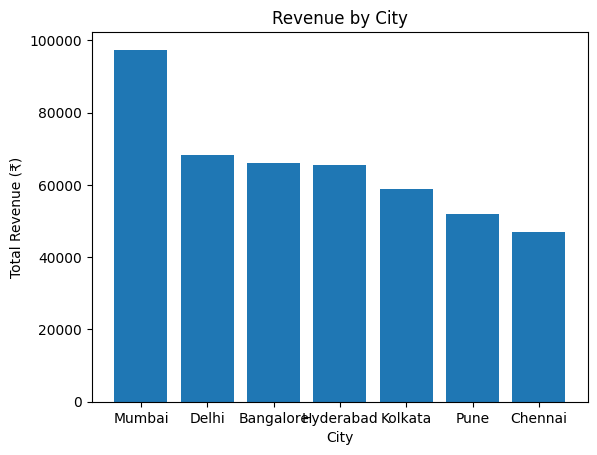

In [9]:
city_revenue = df.groupby("city")["final_amount"].sum().sort_values(ascending=False)
print(city_revenue)

plt.bar(city_revenue.index, city_revenue.values)
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue (₹)")
plt.show()

order_status
Cancelled         NaN
Delayed      2.485714
Delivered    4.161772
Name: customer_rating, dtype: float64


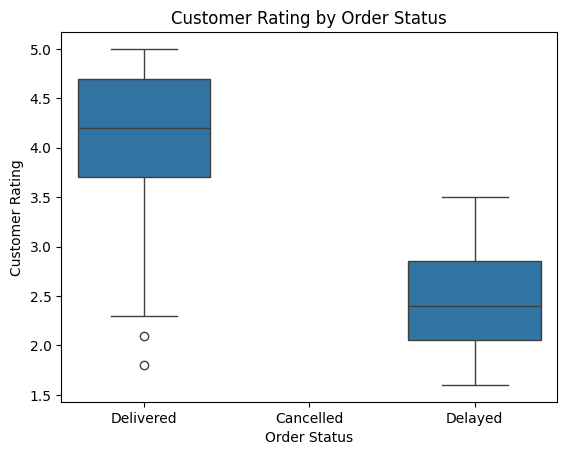

In [10]:
status_rating = df.groupby("order_status")["customer_rating"].mean()
print(status_rating)
sns.boxplot(x=df["order_status"], y=df["customer_rating"])
plt.title("Customer Rating by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Customer Rating")
plt.show()

In [11]:
df.to_csv("/content/drive/MyDrive/foodexpress_cleaned.csv", index=False)